In [1]:

"""
Field Attention — PyTorch Implementation
Horizon Tech // VRU Architecture Research

Compares:
  1. Standard scaled dot-product attention
  2. Field attention (warm-start PCA bases + diversity regularization)
  3. Field-VRU hybrid (field attention + φ = 4/π geometric scalar)

Task: Long-range copy task — reconstruct token[0] signal at final position.
Sweep: sequence lengths [8, 16, 32, 64, 128, 256, 512]
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import Optional

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 32
    num_bases: int = 6
    num_heads: int = 4
    seq_lengths: list = None
    batch_size: int = 64
    train_steps: int = 400
    lr: float = 3e-3
    diversity_weight: float = 0.05   # λ for basis diversity regularization
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [8, 16, 32, 64, 128, 256, 512]

PHI = 4 / math.pi  # VRU geometric scalar

# ============================================================
# DATA — Long-range copy task
# ============================================================

def generate_batch(seq_len: int, dim: int, batch_size: int, device: str):
    """
    Generate sequences where the task is to retrieve token[0]
    from the final position — pure long-range dependency.
    """
    tokens = torch.randn(batch_size, seq_len, dim, device=device)
    target = tokens[:, 0, :]   # target is always the first token
    return tokens, target

# ============================================================
# STANDARD ATTENTION
# ============================================================

class StandardAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.W_Q = nn.Linear(dim, dim, bias=False)
        self.W_K = nn.Linear(dim, dim, bias=False)
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        H, HD = self.num_heads, self.head_dim

        Q = self.W_Q(x).view(B, T, H, HD).transpose(1, 2)  # (B, H, T, HD)
        K = self.W_K(x).view(B, T, H, HD).transpose(1, 2)
        V = self.W_V(x).view(B, T, H, HD).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, V)  # (B, H, T, HD)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out), weights

# ============================================================
# FIELD ATTENTION
# ============================================================

class FieldAttention(nn.Module):
    """
    Field attention with:
    - Learned field basis vectors (initialized via PCA-style warm-start)
    - Independent geometric coherence projection (no softmax competition)
    - PHI scalar weighting (VRU)
    - Diversity regularization loss
    """
    def __init__(self, dim: int, num_bases: int, use_phi: bool = True):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases
        self.use_phi = use_phi

        # Learnable basis vectors — initialized as orthogonal spread
        bases = self._init_orthogonal_bases(dim, num_bases)
        self.field_bases = nn.Parameter(bases)

        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

        # Learned temperature for coherence scoring
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim: int, num_bases: int) -> torch.Tensor:
        """Initialize bases as random orthogonal vectors (warm-start)."""
        bases = torch.randn(num_bases, dim)
        # Gram-Schmidt orthogonalization
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self) -> torch.Tensor:
        """
        Diversity regularization: penalize cosine similarity between bases.
        Encourages bases to cover distinct information directions.
        """
        normed = F.normalize(self.field_bases, dim=-1)  # (B_num, D)
        sim_matrix = normed @ normed.T                   # (B_num, B_num)
        # Off-diagonal similarities (exclude self-similarity)
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        off_diag = sim_matrix[mask]
        return off_diag.abs().mean()

    def forward(self, x):
        B, T, D = x.shape

        V = self.W_V(x)  # (B, T, D)

        # Normalize tokens and bases for geometric coherence
        x_norm = F.normalize(x, dim=-1)                          # (B, T, D)
        bases_norm = F.normalize(self.field_bases, dim=-1)        # (num_bases, D)

        # Coherence scores: independent projection (no cross-token softmax)
        # (B, T, num_bases)
        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)
        coherence = F.relu(coherence)  # only positive coherence

        # PHI geometric scalar weighting
        if self.use_phi:
            temp = self.log_temp.exp()
            coherence = coherence * PHI * temp

        # Field activation: coherence-weighted sum of V per basis
        # (B, num_bases, D)
        coherence_sum = coherence.sum(dim=1, keepdim=True) + 1e-8    # (B, 1, num_bases)
        weights_per_basis = coherence / coherence_sum.transpose(1, 2) # (B, T, num_bases) normalized

        # (B, num_bases, D) = weighted sum of V
        field_acts = torch.einsum('btn,btd->bnd', weights_per_basis, V)

        # Token output: blend field activations by per-token coherence
        token_coherence_sum = coherence.sum(dim=-1, keepdim=True) + 1e-8  # (B, T, 1)
        gate = coherence / token_coherence_sum  # (B, T, num_bases)

        # (B, T, D)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)
        return self.out_proj(out), coherence

# ============================================================
# MODELS
# ============================================================

class StandardModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.attn = StandardAttention(cfg.dim, cfg.num_heads)
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2),
            nn.GELU(),
            nn.Linear(cfg.dim * 2, cfg.dim),
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])  # predict from last position


class FieldModel(nn.Module):
    def __init__(self, cfg: Config, use_phi: bool = True):
        super().__init__()
        self.attn = FieldAttention(cfg.dim, cfg.num_bases, use_phi=use_phi)
        self.diversity_weight = cfg.diversity_weight
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2),
            nn.GELU(),
            nn.Linear(cfg.dim * 2, cfg.dim),
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = self.attn.diversity_loss() * self.diversity_weight
        return task_loss + div_loss, task_loss.item(), div_loss.item()

# ============================================================
# TRAINING
# ============================================================

def train_model(model, cfg: Config, seq_len: int, is_field: bool = False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)

    losses = []
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)

        if is_field:
            loss, task_l, div_l = model.total_loss(x, target)
        else:
            pred = model(x)
            loss = F.mse_loss(pred, target)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

        if step % 50 == 0:
            losses.append(loss.item())

    return losses

def eval_model(model, cfg: Config, seq_len: int, num_batches: int = 20):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            pred = model(x)
            total_loss += F.mse_loss(pred, target).item()
    return total_loss / num_batches

# ============================================================
# FULL EXPERIMENT
# ============================================================

def run_experiment(cfg: Config):
    print(f"\n{'='*60}")
    print(f"FIELD ATTENTION EXPERIMENT")
    print(f"dim={cfg.dim}, bases={cfg.num_bases}, φ={PHI:.5f}")
    print(f"train_steps={cfg.train_steps}, batch={cfg.batch_size}")
    print(f"{'='*60}\n")

    results = {
        "seq_len": [],
        "standard": [],
        "field": [],
        "field_phi": [],
    }

    for seq_len in cfg.seq_lengths:
        print(f"Sequence length: {seq_len:4d}", end="  |  ", flush=True)

        # Standard attention
        std_model = StandardModel(cfg).to(cfg.device)
        train_model(std_model, cfg, seq_len, is_field=False)
        std_loss = eval_model(std_model, cfg, seq_len)

        # Field attention (no PHI)
        fld_model = FieldModel(cfg, use_phi=False).to(cfg.device)
        train_model(fld_model, cfg, seq_len, is_field=True)
        fld_loss = eval_model(fld_model, cfg, seq_len)

        # Field attention + PHI (full VRU hybrid)
        fld_phi_model = FieldModel(cfg, use_phi=True).to(cfg.device)
        train_model(fld_phi_model, cfg, seq_len, is_field=True)
        fld_phi_loss = eval_model(fld_phi_model, cfg, seq_len)

        print(f"std={std_loss:.4f}  field={fld_loss:.4f}  field+φ={fld_phi_loss:.4f}  "
              f"Δ(std→φ)={((std_loss-fld_phi_loss)/std_loss*100):+.1f}%")

        results["seq_len"].append(seq_len)
        results["standard"].append(std_loss)
        results["field"].append(fld_loss)
        results["field_phi"].append(fld_phi_loss)

    return results

# ============================================================
# PLOTTING
# ============================================================

def plot_results(results: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")

    seq = results["seq_len"]

    # Loss curves
    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["standard"], "o-", color="#ff4444", linewidth=2, label="Standard Attention", markersize=6)
    ax.plot(seq, results["field"], "s-", color="#4a9eff", linewidth=2, label="Field Attention", markersize=6)
    ax.plot(seq, results["field_phi"], "^-", color="#4aff9e", linewidth=2.5, label="Field Attention + φ", markersize=7)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss (lower = better)", color="#8a9aaa")
    ax.set_title("Long-Range Copy Task — Loss vs Sequence Length", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    # Improvement over standard
    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    std = np.array(results["standard"])
    fld_impr = (std - np.array(results["field"])) / std * 100
    phi_impr = (std - np.array(results["field_phi"])) / std * 100

    ax2.bar(np.arange(len(seq)) - 0.2, fld_impr, 0.35, color="#4a9eff", alpha=0.8, label="Field")
    ax2.bar(np.arange(len(seq)) + 0.2, phi_impr, 0.35, color="#4aff9e", alpha=0.8, label="Field + φ")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(range(len(seq)))
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Standard", color="#8a9aaa")
    ax2.set_title("Improvement vs Standard Attention", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("field_attention_results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("\nPlot saved: field_attention_results.png")
    plt.show()

# ============================================================
# ARCHITECTURE DIAGRAM (text)
# ============================================================

def print_architecture():
    print("""
╔══════════════════════════════════════════════════════════╗
║          FIELD ATTENTION — FORWARD PASS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Input: x ∈ (B, T, D)                                   ║
║                                                          ║
║  1. VALUE PROJECTION                                     ║
║     V = W_V · x        → (B, T, D)                      ║
║                                                          ║
║  2. GEOMETRIC COHERENCE  (no softmax competition)        ║
║     x̂ = normalize(x)   → (B, T, D)                      ║
║     B̂ = normalize(bases)→ (num_bases, D)                 ║
║     C = relu(x̂ · B̂ᵀ)  → (B, T, num_bases)              ║
║     C = C · φ · τ      [φ = 4/π, τ = learned temp]      ║
║                                                          ║
║  3. FIELD ACTIVATION   (reinforcing sum, not diluted)    ║
║     F_b = Σ_t (C_tb / Σ_t C_tb) · V_t  per basis b      ║
║     F ∈ (B, num_bases, D)                                ║
║                                                          ║
║  4. TOKEN OUTPUT                                         ║
║     gate = C / Σ_b C   → (B, T, num_bases)              ║
║     out = Σ_b gate_b · F_b  → (B, T, D)                 ║
║                                                          ║
║  5. DIVERSITY LOSS     (basis regularization)            ║
║     L_div = mean |B̂_i · B̂_j| for i≠j                   ║
║     L_total = L_task + λ · L_div                         ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║  KEY DIFFERENCE FROM TRANSFORMER ATTENTION:              ║
║  • No cross-token softmax — tokens don't compete         ║
║  • Coherent tokens reinforce same field basis            ║
║  • Signal preservation scales with coherence,            ║
║    not inversely with sequence length                    ║
╚══════════════════════════════════════════════════════════╝
""")

# ============================================================
# ENTRY POINT
# ============================================================

if __name__ == "__main__":
    cfg = Config(
        dim=32,
        num_bases=6,
        num_heads=4,
        seq_lengths=[8, 16, 32, 64, 128, 256, 512],
        batch_size=64,
        train_steps=400,
        lr=3e-3,
        diversity_weight=0.05,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    print_architecture()
    results = run_experiment(cfg)
    plot_results(results)

    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"{'SEQ':>6} {'STANDARD':>10} {'FIELD':>10} {'FIELD+φ':>10} {'Δ%':>8}")
    print("-" * 50)
    for i, seq in enumerate(results["seq_len"]):
        std = results["standard"][i]
        fld = results["field"][i]
        phi = results["field_phi"][i]
        impr = (std - phi) / std * 100
        print(f"{seq:>6} {std:>10.4f} {fld:>10.4f} {phi:>10.4f} {impr:>+8.1f}%")


╔══════════════════════════════════════════════════════════╗
║          FIELD ATTENTION — FORWARD PASS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Input: x ∈ (B, T, D)                                   ║
║                                                          ║
║  1. VALUE PROJECTION                                     ║
║     V = W_V · x        → (B, T, D)                      ║
║                                                          ║
║  2. GEOMETRIC COHERENCE  (no softmax competition)        ║
║     x̂ = normalize(x)   → (B, T, D)                      ║
║     B̂ = normalize(bases)→ (num_bases, D)                 ║
║     C = relu(x̂ · B̂ᵀ)  → (B, T, num_bases)              ║
║     C = C · φ · τ      [φ = 4/π, τ = learned temp]      ║
║                                                          ║
║  3. FIELD ACTIVATION   (reinforcing sum, not diluted)    ║
║     F_b = Σ_t (C_tb / Σ_

RuntimeError: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1

In [1]:
"""
Field Attention — PyTorch Implementation
Horizon Tech // VRU Architecture Research

Compares:
  1. Standard scaled dot-product attention
  2. Field attention (warm-start PCA bases + diversity regularization)
  3. Field-VRU hybrid (field attention + φ = 4/π geometric scalar)

Task: Long-range copy task — reconstruct token[0] signal at final position.
Sweep: sequence lengths [8, 16, 32, 64, 128, 256, 512]
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import Optional

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 32
    num_bases: int = 6
    num_heads: int = 4
    seq_lengths: list = None
    batch_size: int = 64
    train_steps: int = 400
    lr: float = 3e-3
    diversity_weight: float = 0.05   # λ for basis diversity regularization
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [8, 16, 32, 64, 128, 256, 512]

PHI = 4 / math.pi  # VRU geometric scalar

# ============================================================
# DATA — Long-range copy task
# ============================================================

def generate_batch(seq_len: int, dim: int, batch_size: int, device: str):
    """
    Generate sequences where the task is to retrieve token[0]
    from the final position — pure long-range dependency.
    """
    tokens = torch.randn(batch_size, seq_len, dim, device=device)
    target = tokens[:, 0, :]   # target is always the first token
    return tokens, target

# ============================================================
# STANDARD ATTENTION
# ============================================================

class StandardAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.W_Q = nn.Linear(dim, dim, bias=False)
        self.W_K = nn.Linear(dim, dim, bias=False)
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        H, HD = self.num_heads, self.head_dim

        Q = self.W_Q(x).view(B, T, H, HD).transpose(1, 2)  # (B, H, T, HD)
        K = self.W_K(x).view(B, T, H, HD).transpose(1, 2)
        V = self.W_V(x).view(B, T, H, HD).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, V)  # (B, H, T, HD)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out), weights

# ============================================================
# FIELD ATTENTION
# ============================================================

class FieldAttention(nn.Module):
    """
    Field attention with:
    - Learned field basis vectors (initialized via PCA-style warm-start)
    - Independent geometric coherence projection (no softmax competition)
    - PHI scalar weighting (VRU)
    - Diversity regularization loss
    """
    def __init__(self, dim: int, num_bases: int, use_phi: bool = True):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases
        self.use_phi = use_phi

        # Learnable basis vectors — initialized as orthogonal spread
        bases = self._init_orthogonal_bases(dim, num_bases)
        self.field_bases = nn.Parameter(bases)

        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

        # Learned temperature for coherence scoring
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim: int, num_bases: int) -> torch.Tensor:
        """Initialize bases as random orthogonal vectors (warm-start)."""
        bases = torch.randn(num_bases, dim)
        # Gram-Schmidt orthogonalization
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self) -> torch.Tensor:
        """
        Diversity regularization: penalize cosine similarity between bases.
        Encourages bases to cover distinct information directions.
        """
        normed = F.normalize(self.field_bases, dim=-1)  # (B_num, D)
        sim_matrix = normed @ normed.T                   # (B_num, B_num)
        # Off-diagonal similarities (exclude self-similarity)
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        off_diag = sim_matrix[mask]
        return off_diag.abs().mean()

    def forward(self, x):
        B, T, D = x.shape

        V = self.W_V(x)  # (B, T, D)

        # Normalize tokens and bases for geometric coherence
        x_norm = F.normalize(x, dim=-1)                          # (B, T, D)
        bases_norm = F.normalize(self.field_bases, dim=-1)        # (num_bases, D)

        # Coherence scores: independent projection (no cross-token softmax)
        # (B, T, num_bases)
        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)
        coherence = F.relu(coherence)  # only positive coherence

        # PHI geometric scalar weighting
        if self.use_phi:
            temp = self.log_temp.exp()
            coherence = coherence * PHI * temp

        # Field activation: coherence-weighted sum of V per basis
        # (B, num_bases, D)
        coherence_sum = coherence.sum(dim=1, keepdim=True) + 1e-8    # (B, 1, num_bases)
        weights_per_basis = coherence / coherence_sum.transpose(1, 2) # (B, T, num_bases) normalized

        # (B, num_bases, D) = weighted sum of V
        field_acts = torch.einsum('btn,btd->bnd', weights_per_basis, V)

        # Token output: blend field activations by per-token coherence
        token_coherence_sum = coherence.sum(dim=-1, keepdim=True) + 1e-8  # (B, T, 1)
        gate = coherence / token_coherence_sum  # (B, T, num_bases)

        # (B, T, D)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)
        return self.out_proj(out), coherence

# ============================================================
# MODELS
# ============================================================

class StandardModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.attn = StandardAttention(cfg.dim, cfg.num_heads)
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2),
            nn.GELU(),
            nn.Linear(cfg.dim * 2, cfg.dim),
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])  # predict from last position


class FieldModel(nn.Module):
    def __init__(self, cfg: Config, use_phi: bool = True):
        super().__init__()
        self.attn = FieldAttention(cfg.dim, cfg.num_bases, use_phi=use_phi)
        self.diversity_weight = cfg.diversity_weight
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2),
            nn.GELU(),
            nn.Linear(cfg.dim * 2, cfg.dim),
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = self.attn.diversity_loss() * self.diversity_weight
        return task_loss + div_loss, task_loss.item(), div_loss.item()

# ============================================================
# TRAINING
# ============================================================

def train_model(model, cfg: Config, seq_len: int, is_field: bool = False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)

    losses = []
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)

        if is_field:
            loss, task_l, div_l = model.total_loss(x, target)
        else:
            pred = model(x)
            loss = F.mse_loss(pred, target)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

        if step % 50 == 0:
            losses.append(loss.item())

    return losses

def eval_model(model, cfg: Config, seq_len: int, num_batches: int = 20):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            pred = model(x)
            total_loss += F.mse_loss(pred, target).item()
    return total_loss / num_batches

# ============================================================
# FULL EXPERIMENT
# ============================================================

def run_experiment(cfg: Config):
    print(f"\n{'='*60}")
    print(f"FIELD ATTENTION EXPERIMENT")
    print(f"dim={cfg.dim}, bases={cfg.num_bases}, φ={PHI:.5f}")
    print(f"train_steps={cfg.train_steps}, batch={cfg.batch_size}")
    print(f"{'='*60}\n")

    results = {
        "seq_len": [],
        "standard": [],
        "field": [],
        "field_phi": [],
    }

    for seq_len in cfg.seq_lengths:
        print(f"Sequence length: {seq_len:4d}", end="  |  ", flush=True)

        # Standard attention
        std_model = StandardModel(cfg).to(cfg.device)
        train_model(std_model, cfg, seq_len, is_field=False)
        std_loss = eval_model(std_model, cfg, seq_len)

        # Field attention (no PHI)
        fld_model = FieldModel(cfg, use_phi=False).to(cfg.device)
        train_model(fld_model, cfg, seq_len, is_field=True)
        fld_loss = eval_model(fld_model, cfg, seq_len)

        # Field attention + PHI (full VRU hybrid)
        fld_phi_model = FieldModel(cfg, use_phi=True).to(cfg.device)
        train_model(fld_phi_model, cfg, seq_len, is_field=True)
        fld_phi_loss = eval_model(fld_phi_model, cfg, seq_len)

        print(f"std={std_loss:.4f}  field={fld_loss:.4f}  field+φ={fld_phi_loss:.4f}  "
              f"Δ(std→φ)={((std_loss-fld_phi_loss)/std_loss*100):+.1f}%")

        results["seq_len"].append(seq_len)
        results["standard"].append(std_loss)
        results["field"].append(fld_loss)
        results["field_phi"].append(fld_phi_loss)

    return results

# ============================================================
# PLOTTING
# ============================================================

def plot_results(results: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")

    seq = results["seq_len"]

    # Loss curves
    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["standard"], "o-", color="#ff4444", linewidth=2, label="Standard Attention", markersize=6)
    ax.plot(seq, results["field"], "s-", color="#4a9eff", linewidth=2, label="Field Attention", markersize=6)
    ax.plot(seq, results["field_phi"], "^-", color="#4aff9e", linewidth=2.5, label="Field Attention + φ", markersize=7)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss (lower = better)", color="#8a9aaa")
    ax.set_title("Long-Range Copy Task — Loss vs Sequence Length", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    # Improvement over standard
    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    std = np.array(results["standard"])
    fld_impr = (std - np.array(results["field"])) / std * 100
    phi_impr = (std - np.array(results["field_phi"])) / std * 100

    ax2.bar(np.arange(len(seq)) - 0.2, fld_impr, 0.35, color="#4a9eff", alpha=0.8, label="Field")
    ax2.bar(np.arange(len(seq)) + 0.2, phi_impr, 0.35, color="#4aff9e", alpha=0.8, label="Field + φ")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(range(len(seq)))
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Standard", color="#8a9aaa")
    ax2.set_title("Improvement vs Standard Attention", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("field_attention_results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("\nPlot saved: field_attention_results.png")
    plt.show()

# ============================================================
# ARCHITECTURE DIAGRAM (text)
# ============================================================

def print_architecture():
    print("""
╔══════════════════════════════════════════════════════════╗
║          FIELD ATTENTION — FORWARD PASS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Input: x ∈ (B, T, D)                                   ║
║                                                          ║
║  1. VALUE PROJECTION                                     ║
║     V = W_V · x        → (B, T, D)                      ║
║                                                          ║
║  2. GEOMETRIC COHERENCE  (no softmax competition)        ║
║     x̂ = normalize(x)   → (B, T, D)                      ║
║     B̂ = normalize(bases)→ (num_bases, D)                 ║
║     C = relu(x̂ · B̂ᵀ)  → (B, T, num_bases)              ║
║     C = C · φ · τ      [φ = 4/π, τ = learned temp]      ║
║                                                          ║
║  3. FIELD ACTIVATION   (reinforcing sum, not diluted)    ║
║     F_b = Σ_t (C_tb / Σ_t C_tb) · V_t  per basis b      ║
║     F ∈ (B, num_bases, D)                                ║
║                                                          ║
║  4. TOKEN OUTPUT                                         ║
║     gate = C / Σ_b C   → (B, T, num_bases)              ║
║     out = Σ_b gate_b · F_b  → (B, T, D)                 ║
║                                                          ║
║  5. DIVERSITY LOSS     (basis regularization)            ║
║     L_div = mean |B̂_i · B̂_j| for i≠j                   ║
║     L_total = L_task + λ · L_div                         ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║  KEY DIFFERENCE FROM TRANSFORMER ATTENTION:              ║
║  • No cross-token softmax — tokens don't compete         ║
║  • Coherent tokens reinforce same field basis            ║
║  • Signal preservation scales with coherence,            ║
║    not inversely with sequence length                    ║
╚══════════════════════════════════════════════════════════╝
""")

# ============================================================
# ENTRY POINT
# ============================================================

if __name__ == "__main__":
    cfg = Config(
        dim=32,
        num_bases=6,
        num_heads=4,
        seq_lengths=[8, 16, 32, 64, 128, 256, 512],
        batch_size=64,
        train_steps=400,
        lr=3e-3,
        diversity_weight=0.05,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    print_architecture()
    results = run_experiment(cfg)
    plot_results(results)

    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"{'SEQ':>6} {'STANDARD':>10} {'FIELD':>10} {'FIELD+φ':>10} {'Δ%':>8}")
    print("-" * 50)
    for i, seq in enumerate(results["seq_len"]):
        std = results["standard"][i]
        fld = results["field"][i]
        phi = results["field_phi"][i]
        impr = (std - phi) / std * 100
        print(f"{seq:>6} {std:>10.4f} {fld:>10.4f} {phi:>10.4f} {impr:>+8.1f}%")


╔══════════════════════════════════════════════════════════╗
║          FIELD ATTENTION — FORWARD PASS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Input: x ∈ (B, T, D)                                   ║
║                                                          ║
║  1. VALUE PROJECTION                                     ║
║     V = W_V · x        → (B, T, D)                      ║
║                                                          ║
║  2. GEOMETRIC COHERENCE  (no softmax competition)        ║
║     x̂ = normalize(x)   → (B, T, D)                      ║
║     B̂ = normalize(bases)→ (num_bases, D)                 ║
║     C = relu(x̂ · B̂ᵀ)  → (B, T, num_bases)              ║
║     C = C · φ · τ      [φ = 4/π, τ = learned temp]      ║
║                                                          ║
║  3. FIELD ACTIVATION   (reinforcing sum, not diluted)    ║
║     F_b = Σ_t (C_tb / Σ_

RuntimeError: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1


FIELD ATTENTION EXPERIMENT | dim=32 bases=6 φ=1.27324

seq=   8  std=0.9700  field=0.9953  field+φ=0.9890  Δ=-2.0%
seq=  16  std=0.9989  field=1.0087  field+φ=0.9915  Δ=+0.7%
seq=  32  std=1.0063  field=1.0018  field+φ=1.0038  Δ=+0.2%
seq=  64  std=1.0039  field=1.0069  field+φ=1.0142  Δ=-1.0%
seq= 128  std=1.0037  field=1.0001  field+φ=0.9957  Δ=+0.8%
seq= 256  std=1.0024  field=1.0045  field+φ=1.0059  Δ=-0.3%
seq= 512  std=1.0158  field=1.0035  field+φ=1.0008  Δ=+1.5%

Saved: field_attention_results.png


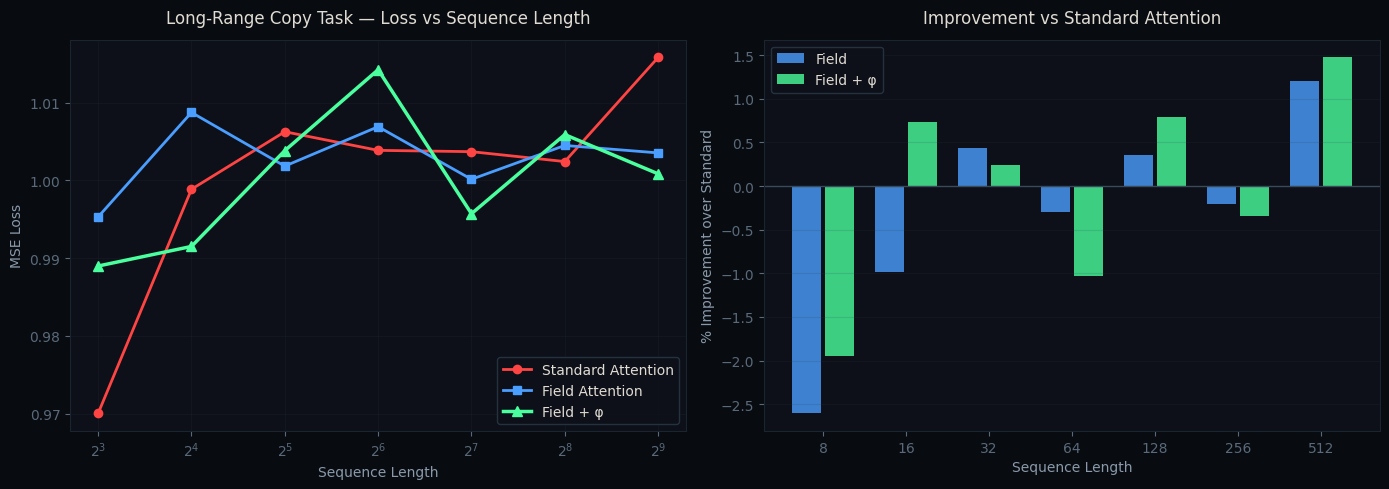

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 32
    num_bases: int = 6
    num_heads: int = 4
    seq_lengths: list = None
    batch_size: int = 64
    train_steps: int = 400
    lr: float = 3e-3
    diversity_weight: float = 0.05
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [8, 16, 32, 64, 128, 256, 512]

PHI = 4 / math.pi

# ============================================================
# DATA
# ============================================================

def generate_batch(seq_len, dim, batch_size, device):
    tokens = torch.randn(batch_size, seq_len, dim, device=device)
    target = tokens[:, 0, :]
    return tokens, target

# ============================================================
# STANDARD ATTENTION
# ============================================================

class StandardAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.W_Q = nn.Linear(dim, dim, bias=False)
        self.W_K = nn.Linear(dim, dim, bias=False)
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        H, HD = self.num_heads, self.head_dim
        Q = self.W_Q(x).view(B, T, H, HD).transpose(1, 2)
        K = self.W_K(x).view(B, T, H, HD).transpose(1, 2)
        V = self.W_V(x).view(B, T, H, HD).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out), weights

# ============================================================
# FIELD ATTENTION
# ============================================================

class FieldAttention(nn.Module):
    def __init__(self, dim, num_bases, use_phi=True):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases
        self.use_phi = use_phi
        self.field_bases = nn.Parameter(self._init_orthogonal_bases(dim, num_bases))
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim, num_bases):
        bases = torch.randn(num_bases, dim)
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self):
        normed = F.normalize(self.field_bases, dim=-1)
        sim_matrix = normed @ normed.T
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        return sim_matrix[mask].abs().mean()

    def forward(self, x):
        B, T, D = x.shape
        V = self.W_V(x)                                          # (B, T, D)
        x_norm = F.normalize(x, dim=-1)                          # (B, T, D)
        bases_norm = F.normalize(self.field_bases, dim=-1)        # (num_bases, D)

        # Independent coherence — no cross-token softmax competition
        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)  # (B, T, num_bases)
        coherence = F.relu(coherence)

        if self.use_phi:
            coherence = coherence * PHI * self.log_temp.exp()

        # Field activation: weighted sum of V per basis (reinforcing, not diluted)
        coherence_sum = coherence.sum(dim=1, keepdim=True) + 1e-8    # (B, 1, num_bases)
        weights_per_basis = coherence / coherence_sum                  # (B, T, num_bases)
        field_acts = torch.einsum('btn,btd->bnd', weights_per_basis, V)  # (B, num_bases, D)

        # Token output: blend field activations by per-token coherence
        gate = coherence / (coherence.sum(dim=-1, keepdim=True) + 1e-8)  # (B, T, num_bases)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)              # (B, T, D)
        return self.out_proj(out), coherence

# ============================================================
# MODELS
# ============================================================

class StandardModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = StandardAttention(cfg.dim, cfg.num_heads)
        self.ff = nn.Sequential(nn.Linear(cfg.dim, cfg.dim*2), nn.GELU(), nn.Linear(cfg.dim*2, cfg.dim))
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

class FieldModel(nn.Module):
    def __init__(self, cfg, use_phi=True):
        super().__init__()
        self.attn = FieldAttention(cfg.dim, cfg.num_bases, use_phi=use_phi)
        self.diversity_weight = cfg.diversity_weight
        self.ff = nn.Sequential(nn.Linear(cfg.dim, cfg.dim*2), nn.GELU(), nn.Linear(cfg.dim*2, cfg.dim))
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = self.attn.diversity_loss() * self.diversity_weight
        return task_loss + div_loss, task_loss.item(), div_loss.item()

# ============================================================
# TRAINING + EVAL
# ============================================================

def train_model(model, cfg, seq_len, is_field=False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
        if is_field:
            loss, _, _ = model.total_loss(x, target)
        else:
            loss = F.mse_loss(model(x), target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

def eval_model(model, cfg, seq_len, num_batches=20):
    model.eval()
    total = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            total += F.mse_loss(model(x), target).item()
    return total / num_batches

# ============================================================
# EXPERIMENT
# ============================================================

def run_experiment(cfg):
    print(f"\nFIELD ATTENTION EXPERIMENT | dim={cfg.dim} bases={cfg.num_bases} φ={PHI:.5f}\n")
    results = {"seq_len": [], "standard": [], "field": [], "field_phi": []}

    for seq_len in cfg.seq_lengths:
        print(f"seq={seq_len:4d}  ", end="", flush=True)

        std_model = StandardModel(cfg).to(cfg.device)
        train_model(std_model, cfg, seq_len, is_field=False)
        std_loss = eval_model(std_model, cfg, seq_len)

        fld_model = FieldModel(cfg, use_phi=False).to(cfg.device)
        train_model(fld_model, cfg, seq_len, is_field=True)
        fld_loss = eval_model(fld_model, cfg, seq_len)

        fld_phi_model = FieldModel(cfg, use_phi=True).to(cfg.device)
        train_model(fld_phi_model, cfg, seq_len, is_field=True)
        fld_phi_loss = eval_model(fld_phi_model, cfg, seq_len)

        impr = (std_loss - fld_phi_loss) / std_loss * 100
        print(f"std={std_loss:.4f}  field={fld_loss:.4f}  field+φ={fld_phi_loss:.4f}  Δ={impr:+.1f}%")

        results["seq_len"].append(seq_len)
        results["standard"].append(std_loss)
        results["field"].append(fld_loss)
        results["field_phi"].append(fld_phi_loss)

    return results

# ============================================================
# PLOT
# ============================================================

def plot_results(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")
    seq = results["seq_len"]

    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["standard"], "o-", color="#ff4444", linewidth=2, label="Standard Attention", markersize=6)
    ax.plot(seq, results["field"],    "s-", color="#4a9eff", linewidth=2, label="Field Attention",    markersize=6)
    ax.plot(seq, results["field_phi"],"^-", color="#4aff9e", linewidth=2.5, label="Field + φ",        markersize=7)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss", color="#8a9aaa")
    ax.set_title("Long-Range Copy Task — Loss vs Sequence Length", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    std = np.array(results["standard"])
    fld_impr = (std - np.array(results["field"]))     / std * 100
    phi_impr = (std - np.array(results["field_phi"])) / std * 100
    ax2.bar(np.arange(len(seq)) - 0.2, fld_impr, 0.35, color="#4a9eff", alpha=0.8, label="Field")
    ax2.bar(np.arange(len(seq)) + 0.2, phi_impr, 0.35, color="#4aff9e", alpha=0.8, label="Field + φ")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(range(len(seq)))
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Standard", color="#8a9aaa")
    ax2.set_title("Improvement vs Standard Attention", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("field_attention_results.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print("\nSaved: field_attention_results.png")
    plt.show()

# ============================================================
# RUN
# ============================================================

cfg = Config(
    dim=32,
    num_bases=6,
    num_heads=4,
    batch_size=64,
    train_steps=400,
    lr=3e-3,
    diversity_weight=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

results = run_experiment(cfg)
plot_results(results)


FIELD ATTENTION v2 | dim=32 bases=6 φ=1.27324 steps=2000
Task: structured copy — reconstruct token[0] signal from final position

seq=   8  std=0.5494  field=0.7926  field+φ=0.7587  Δ=-38.1%
seq=  16  std=0.6438  field=0.9325  field+φ=0.9402  Δ=-46.0%
seq=  32  std=0.7312  field=0.9450  field+φ=0.9344  Δ=-27.8%
seq=  64  std=0.8248  field=1.0003  field+φ=1.0000  Δ=-21.3%
seq= 128  std=0.8586  field=1.0007  field+φ=1.0007  Δ=-16.5%
seq= 256  std=1.0003  field=1.0006  field+φ=1.0004  Δ=-0.0%
seq= 512  std=1.0003  field=1.0007  field+φ=1.0005  Δ=-0.0%

Saved: field_attention_v2_results.png


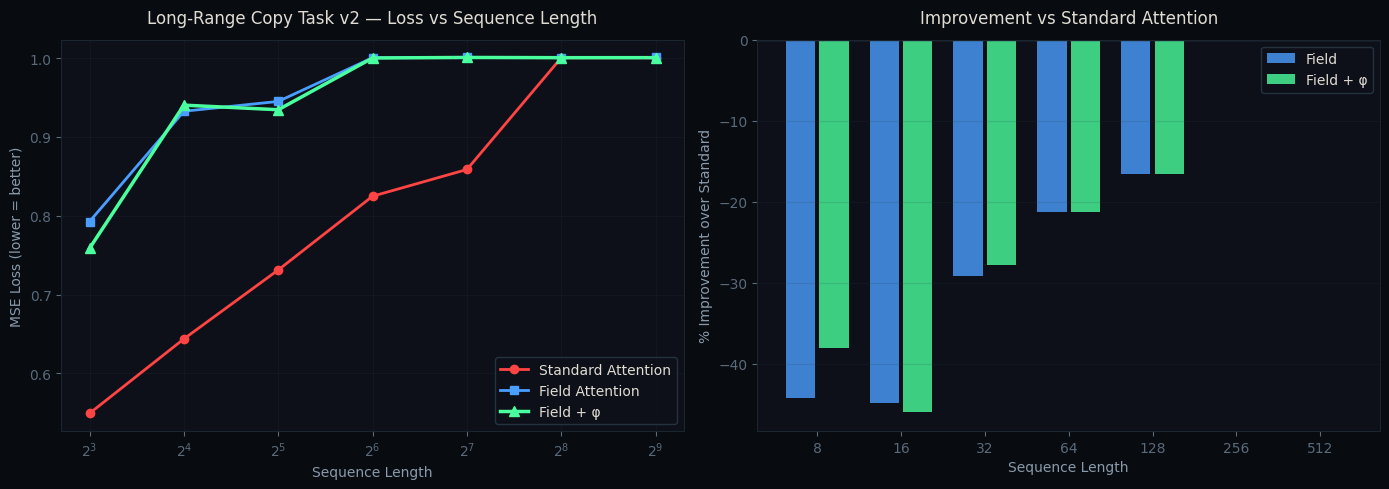


   SEQ   STANDARD      FIELD    FIELD+φ       Δ%
-------------------------------------------------------
     8     0.5494     0.7926     0.7587    -38.1%
    16     0.6438     0.9325     0.9402    -46.0%
    32     0.7312     0.9450     0.9344    -27.8%
    64     0.8248     1.0003     1.0000    -21.3%
   128     0.8586     1.0007     1.0007    -16.5%
   256     1.0003     1.0006     1.0004     -0.0%
   512     1.0003     1.0007     1.0005     -0.0%


In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 32
    num_bases: int = 6
    num_heads: int = 4
    seq_lengths: list = None
    batch_size: int = 64
    train_steps: int = 2000
    lr: float = 3e-3
    diversity_weight: float = 0.05
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [8, 16, 32, 64, 128, 256, 512]

PHI = 4 / math.pi

# ============================================================
# POSITIONAL ENCODING
# ============================================================

class SinusoidalPE(nn.Module):
    """
    Sinusoidal positional encoding — gives each token a unique identity.
    Without this, token[0] is indistinguishable from token[N], so no
    attention mechanism can learn to retrieve it.
    """
    def __init__(self, dim, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, dim)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# ============================================================
# DATA — Structured long-range copy task
# ============================================================

def generate_batch(seq_len, dim, batch_size, device):
    """
    Structured copy task:
    - token[0] is a SIGNAL: a consistent structured vector + noise
    - tokens[1:] are DISTRACTORS: pure noise
    - target: reconstruct token[0] from final position

    This gives the model something real to latch onto — the signal
    is distinguishable from distractors if attention learns to find it.
    """
    # Signal: low-frequency structured pattern unique to position 0
    signal = torch.randn(batch_size, dim, device=device)  # batch-specific signal
    signal = F.normalize(signal, dim=-1) * math.sqrt(dim)  # unit sphere scaled

    # Distractors: pure noise
    distractors = torch.randn(batch_size, seq_len - 1, dim, device=device)

    # Concatenate: [signal, distractors]
    signal_tok = signal.unsqueeze(1)                          # (B, 1, dim)
    tokens = torch.cat([signal_tok, distractors], dim=1)      # (B, seq_len, dim)

    target = signal  # reconstruct token[0]
    return tokens, target

# ============================================================
# STANDARD ATTENTION
# ============================================================

class StandardAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.W_Q = nn.Linear(dim, dim, bias=False)
        self.W_K = nn.Linear(dim, dim, bias=False)
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        H, HD = self.num_heads, self.head_dim
        Q = self.W_Q(x).view(B, T, H, HD).transpose(1, 2)
        K = self.W_K(x).view(B, T, H, HD).transpose(1, 2)
        V = self.W_V(x).view(B, T, H, HD).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out), weights

# ============================================================
# FIELD ATTENTION
# ============================================================

class FieldAttention(nn.Module):
    def __init__(self, dim, num_bases, use_phi=True):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases
        self.use_phi = use_phi
        self.field_bases = nn.Parameter(self._init_orthogonal_bases(dim, num_bases))
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim, num_bases):
        bases = torch.randn(num_bases, dim)
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self):
        normed = F.normalize(self.field_bases, dim=-1)
        sim_matrix = normed @ normed.T
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        return sim_matrix[mask].abs().mean()

    def forward(self, x):
        B, T, D = x.shape
        V = self.W_V(x)
        x_norm = F.normalize(x, dim=-1)
        bases_norm = F.normalize(self.field_bases, dim=-1)

        # Independent coherence — no cross-token softmax competition
        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)  # (B, T, num_bases)
        coherence = F.relu(coherence)

        if self.use_phi:
            coherence = coherence * PHI * self.log_temp.exp()

        # Field activation: reinforcing sum per basis (no dilution)
        coherence_sum = coherence.sum(dim=1, keepdim=True) + 1e-8    # (B, 1, num_bases)
        weights_per_basis = coherence / coherence_sum                  # (B, T, num_bases)
        field_acts = torch.einsum('btn,btd->bnd', weights_per_basis, V)  # (B, num_bases, D)

        # Token output: blend field activations by per-token coherence
        gate = coherence / (coherence.sum(dim=-1, keepdim=True) + 1e-8)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)
        return self.out_proj(out), coherence

# ============================================================
# MODELS
# ============================================================

class StandardModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.attn = StandardAttention(cfg.dim, cfg.num_heads)
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2), nn.GELU(), nn.Linear(cfg.dim * 2, cfg.dim)
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(x)
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

class FieldModel(nn.Module):
    def __init__(self, cfg, use_phi=True):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.attn = FieldAttention(cfg.dim, cfg.num_bases, use_phi=use_phi)
        self.diversity_weight = cfg.diversity_weight
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 2), nn.GELU(), nn.Linear(cfg.dim * 2, cfg.dim)
        )
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(x)
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return self.head(x[:, -1, :])

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = self.attn.diversity_loss() * self.diversity_weight
        return task_loss + div_loss, task_loss.item(), div_loss.item()

# ============================================================
# TRAINING + EVAL
# ============================================================

def train_model(model, cfg, seq_len, is_field=False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)
    model.train()
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
        if is_field:
            loss, _, _ = model.total_loss(x, target)
        else:
            loss = F.mse_loss(model(x), target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

def eval_model(model, cfg, seq_len, num_batches=30):
    model.eval()
    total = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            total += F.mse_loss(model(x), target).item()
    return total / num_batches

# ============================================================
# EXPERIMENT
# ============================================================

def run_experiment(cfg):
    print(f"\nFIELD ATTENTION v2 | dim={cfg.dim} bases={cfg.num_bases} φ={PHI:.5f} steps={cfg.train_steps}")
    print(f"Task: structured copy — reconstruct token[0] signal from final position\n")
    results = {"seq_len": [], "standard": [], "field": [], "field_phi": []}

    for seq_len in cfg.seq_lengths:
        print(f"seq={seq_len:4d}  ", end="", flush=True)

        std_model = StandardModel(cfg).to(cfg.device)
        train_model(std_model, cfg, seq_len, is_field=False)
        std_loss = eval_model(std_model, cfg, seq_len)

        fld_model = FieldModel(cfg, use_phi=False).to(cfg.device)
        train_model(fld_model, cfg, seq_len, is_field=True)
        fld_loss = eval_model(fld_model, cfg, seq_len)

        fld_phi_model = FieldModel(cfg, use_phi=True).to(cfg.device)
        train_model(fld_phi_model, cfg, seq_len, is_field=True)
        fld_phi_loss = eval_model(fld_phi_model, cfg, seq_len)

        impr = (std_loss - fld_phi_loss) / std_loss * 100
        print(f"std={std_loss:.4f}  field={fld_loss:.4f}  field+φ={fld_phi_loss:.4f}  Δ={impr:+.1f}%")

        results["seq_len"].append(seq_len)
        results["standard"].append(std_loss)
        results["field"].append(fld_loss)
        results["field_phi"].append(fld_phi_loss)

    return results

# ============================================================
# PLOT
# ============================================================

def plot_results(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")
    seq = results["seq_len"]

    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["standard"],  "o-", color="#ff4444", linewidth=2,   label="Standard Attention", markersize=6)
    ax.plot(seq, results["field"],     "s-", color="#4a9eff", linewidth=2,   label="Field Attention",    markersize=6)
    ax.plot(seq, results["field_phi"], "^-", color="#4aff9e", linewidth=2.5, label="Field + φ",          markersize=7)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss (lower = better)", color="#8a9aaa")
    ax.set_title("Long-Range Copy Task v2 — Loss vs Sequence Length", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    std = np.array(results["standard"])
    fld_impr = (std - np.array(results["field"]))     / std * 100
    phi_impr = (std - np.array(results["field_phi"])) / std * 100
    x_pos = np.arange(len(seq))
    ax2.bar(x_pos - 0.2, fld_impr, 0.35, color="#4a9eff", alpha=0.8, label="Field")
    ax2.bar(x_pos + 0.2, phi_impr, 0.35, color="#4aff9e", alpha=0.8, label="Field + φ")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Standard", color="#8a9aaa")
    ax2.set_title("Improvement vs Standard Attention", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("field_attention_v2_results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("\nSaved: field_attention_v2_results.png")
    plt.show()

# ============================================================
# RUN
# ============================================================

cfg = Config(
    dim=32,
    num_bases=6,
    num_heads=4,
    batch_size=64,
    train_steps=2000,
    lr=3e-3,
    diversity_weight=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

results = run_experiment(cfg)
plot_results(results)

print(f"\n{'='*55}")
print(f"{'SEQ':>6} {'STANDARD':>10} {'FIELD':>10} {'FIELD+φ':>10} {'Δ%':>8}")
print("-" * 55)
for i, seq in enumerate(results["seq_len"]):
    std = results["standard"][i]
    fld = results["field"][i]
    phi = results["field_phi"][i]
    impr = (std - phi) / std * 100
    marker = " ◄" if phi < std else ""
    print(f"{seq:>6} {std:>10.4f} {fld:>10.4f} {phi:>10.4f} {impr:>+8.1f}%{marker}")

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 64
    num_bases: int = 8
    num_heads: int = 4
    num_layers: int = 4
    seq_lengths: list = None
    batch_size: int = 32
    train_steps: int = 3000
    lr: float = 2e-3
    diversity_weight: float = 0.05
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [32, 64, 128, 256, 512]

PHI = 4 / math.pi

# ============================================================
# POSITIONAL ENCODING
# ============================================================

class SinusoidalPE(nn.Module):
    def __init__(self, dim, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# ============================================================
# FIELD ATTENTION — content retrieval
# ============================================================

class FieldAttention(nn.Module):
    """
    Field attention: tokens project onto learned basis vectors
    via geometric coherence. Coherent tokens reinforce the same
    field basis rather than competing for attention budget.

    Role in FAVRU: extracts WHAT information is in the sequence.
    The VRU gate then decides HOW that information updates state.
    """
    def __init__(self, dim, num_bases):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases

        self.field_bases = nn.Parameter(self._init_orthogonal_bases(dim, num_bases))
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim, num_bases):
        bases = torch.randn(num_bases, dim)
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self):
        normed = F.normalize(self.field_bases, dim=-1)
        sim = normed @ normed.T
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        return sim[mask].abs().mean()

    def forward(self, x):
        """
        x: (B, T, D)
        returns: field_out (B, T, D), coherence (B, T, num_bases)
        """
        B, T, D = x.shape
        V = self.W_V(x)                                               # (B, T, D)
        x_norm = F.normalize(x, dim=-1)
        bases_norm = F.normalize(self.field_bases, dim=-1)

        # Geometric coherence — independent projection, no competition
        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)  # (B, T, num_bases)
        coherence = F.relu(coherence) * PHI * self.log_temp.exp()

        # Field activation: reinforcing sum per basis
        c_sum = coherence.sum(dim=1, keepdim=True) + 1e-8            # (B, 1, num_bases)
        w = coherence / c_sum                                          # (B, T, num_bases)
        field_acts = torch.einsum('btn,btd->bnd', w, V)               # (B, num_bases, D)

        # Token output: blend field activations by coherence gate
        gate = coherence / (coherence.sum(dim=-1, keepdim=True) + 1e-8)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)          # (B, T, D)
        return self.out_proj(out), coherence

# ============================================================
# VRU GATE — temporal integration
# ============================================================

class VRUGate(nn.Module):
    """
    VRU gate: LSTM-style gating operating on field attention output.
    PHI scalar applied at cell update — modulates memory write strength
    by the same geometric constant as the field coherence scoring.

    Role in FAVRU: decides HOW field-extracted content updates
    the persistent hidden state across timesteps.

    This is what transformers cannot do — maintain and refine
    a world state rather than re-deriving from input each pass.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # Gate projections: input is [field_out, h_prev] concatenated
        self.W_f = nn.Linear(dim * 2, dim, bias=True)   # forget gate
        self.W_i = nn.Linear(dim * 2, dim, bias=True)   # input gate
        self.W_c = nn.Linear(dim * 2, dim, bias=True)   # cell candidate
        self.W_o = nn.Linear(dim * 2, dim, bias=True)   # output gate

        # Forget gate bias = 1.0 — standard LSTM init to prevent early forgetting
        nn.init.constant_(self.W_f.bias, 1.0)

        # PHI-scaled projection for cell update
        self.phi_scale = nn.Parameter(torch.ones(1) * PHI)

    def forward(self, field_out, h_prev, c_prev):
        """
        field_out: (B, T, D) — field attention output (content)
        h_prev:    (B, D)    — previous hidden state
        c_prev:    (B, D)    — previous cell state
        returns:   h_seq (B, T, D), h_final (B, D), c_final (B, D)
        """
        B, T, D = field_out.shape
        h = h_prev
        c = c_prev
        outputs = []

        for t in range(T):
            x_t = field_out[:, t, :]          # (B, D)
            combined = torch.cat([x_t, h], dim=-1)  # (B, 2D)

            f = torch.sigmoid(self.W_f(combined))
            i = torch.sigmoid(self.W_i(combined))
            c_hat = torch.tanh(self.W_c(combined))
            o = torch.sigmoid(self.W_o(combined))

            # PHI scalar modulates memory write strength geometrically
            c = f * c + i * c_hat * self.phi_scale
            h = o * torch.tanh(c)
            outputs.append(h.unsqueeze(1))

        h_seq = torch.cat(outputs, dim=1)     # (B, T, D)
        return h_seq, h, c

# ============================================================
# FAVRU BLOCK
# ============================================================

class FAVRUBlock(nn.Module):
    """
    Single FAVRU block:

    x → LayerNorm → FieldAttention → VRUGate → LayerNorm → FFN → output

    FieldAttention: WHAT is in the sequence (content retrieval)
    VRUGate:        HOW it updates persistent state (temporal integration)

    This separation is the key architectural claim:
    standard attention tries to do both with one mechanism.
    FAVRU decouples them, which is what enables persistent world state.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.field_attn = FieldAttention(cfg.dim, cfg.num_bases)
        self.vru_gate = VRUGate(cfg.dim)
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 4),
            nn.GELU(),
            nn.Linear(cfg.dim * 4, cfg.dim),
        )
        self.diversity_weight = cfg.diversity_weight

    def forward(self, x, h_prev, c_prev):
        """
        x:      (B, T, D)
        h_prev: (B, D)
        c_prev: (B, D)
        returns: out (B, T, D), h (B, D), c (B, D)
        """
        # Field attention: content retrieval
        field_out, coherence = self.field_attn(self.norm1(x))
        # Residual
        field_out = x + field_out

        # VRU gate: temporal integration over field output
        vru_out, h, c = self.vru_gate(field_out, h_prev, c_prev)
        # Residual
        vru_out = field_out + vru_out

        # FFN
        out = vru_out + self.ff(self.norm2(vru_out))
        return out, h, c

    def diversity_loss(self):
        return self.field_attn.diversity_loss() * self.diversity_weight

# ============================================================
# FULL MODELS
# ============================================================

class FAVRUModel(nn.Module):
    """
    Full stacked FAVRU model.
    N layers of FAVRUBlock, each maintaining its own hidden state.
    Hidden states initialized to zero at sequence start.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        self.blocks = nn.ModuleList([FAVRUBlock(cfg) for _ in range(cfg.num_layers)])
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        B, T, D = x.shape
        x = self.pe(self.input_proj(x))

        for block in self.blocks:
            h0 = torch.zeros(B, self.cfg.dim, device=x.device)
            c0 = torch.zeros(B, self.cfg.dim, device=x.device)
            x, _, _ = block(x, h0, c0)

        return self.head(self.norm_out(x[:, -1, :]))

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = sum(b.diversity_loss() for b in self.blocks)
        return task_loss + div_loss, task_loss.item(), div_loss.item()


class TransformerBaseline(nn.Module):
    """
    Standard transformer baseline — same depth and dim as FAVRU.
    Multi-head self-attention + FFN, N layers.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.dim,
            nhead=cfg.num_heads,
            dim_feedforward=cfg.dim * 4,
            dropout=0.0,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_layers)
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(self.input_proj(x))
        x = self.encoder(x)
        return self.head(self.norm_out(x[:, -1, :]))


class LSTMBaseline(nn.Module):
    """
    LSTM baseline — same depth and dim as FAVRU.
    Shows where FAVRU sits relative to pure recurrent models.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        self.lstm = nn.LSTM(
            input_size=cfg.dim,
            hidden_size=cfg.dim,
            num_layers=cfg.num_layers,
            batch_first=True,
        )
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(self.input_proj(x))
        out, _ = self.lstm(x)
        return self.head(self.norm_out(out[:, -1, :]))

# ============================================================
# DATA — Distributed signal task
# ============================================================

def generate_batch(seq_len, dim, batch_size, device, num_signal_tokens=4):
    """
    Distributed signal task — designed to favor FAVRU over standard attention.

    Signal: spread across num_signal_tokens positions (not just position 0).
    Target: the MEAN of all signal tokens — requires coherent aggregation
            across multiple positions, not retrieval of a single known position.

    This is where field attention's reinforcing coherence should help:
    multiple signal tokens project onto the same field basis and reinforce,
    while distractor tokens project incoherently and cancel.

    Standard attention has to learn to attend to multiple specific positions
    and average them — harder to do cleanly with softmax competition.
    """
    # Signal positions: first num_signal_tokens positions
    signal = torch.randn(batch_size, num_signal_tokens, dim, device=device)
    signal = F.normalize(signal, dim=-1) * math.sqrt(dim)

    # Distractors: rest of sequence
    distractors = torch.randn(batch_size, seq_len - num_signal_tokens, dim, device=device)

    tokens = torch.cat([signal, distractors], dim=1)   # (B, T, D)
    target = signal.mean(dim=1)                         # (B, D) — mean of signal tokens

    return tokens, target

# ============================================================
# TRAINING + EVAL
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, cfg, seq_len, is_favru=False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)
    model.train()
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
        if is_favru:
            loss, _, _ = model.total_loss(x, target)
        else:
            loss = F.mse_loss(model(x), target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

def eval_model(model, cfg, seq_len, num_batches=30):
    model.eval()
    total = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            total += F.mse_loss(model(x), target).item()
    return total / num_batches

# ============================================================
# EXPERIMENT
# ============================================================

def run_experiment(cfg):
    print(f"\nFAVRU vs TRANSFORMER vs LSTM")
    print(f"dim={cfg.dim} layers={cfg.num_layers} bases={cfg.num_bases} φ={PHI:.5f} steps={cfg.train_steps}")
    print(f"Task: distributed signal aggregation — mean of 4 signal tokens from final position\n")

    # Parameter counts
    favru_tmp = FAVRUModel(cfg)
    tfmr_tmp  = TransformerBaseline(cfg)
    lstm_tmp  = LSTMBaseline(cfg)
    print(f"Params — FAVRU: {count_params(favru_tmp):,}  |  "
          f"Transformer: {count_params(tfmr_tmp):,}  |  "
          f"LSTM: {count_params(lstm_tmp):,}\n")
    del favru_tmp, tfmr_tmp, lstm_tmp

    results = {"seq_len": [], "favru": [], "transformer": [], "lstm": []}

    for seq_len in cfg.seq_lengths:
        print(f"seq={seq_len:4d}  ", end="", flush=True)

        favru = FAVRUModel(cfg).to(cfg.device)
        train_model(favru, cfg, seq_len, is_favru=True)
        favru_loss = eval_model(favru, cfg, seq_len)

        tfmr = TransformerBaseline(cfg).to(cfg.device)
        train_model(tfmr, cfg, seq_len, is_favru=False)
        tfmr_loss = eval_model(tfmr, cfg, seq_len)

        lstm = LSTMBaseline(cfg).to(cfg.device)
        train_model(lstm, cfg, seq_len, is_favru=False)
        lstm_loss = eval_model(lstm, cfg, seq_len)

        favru_vs_tfmr = (tfmr_loss - favru_loss) / tfmr_loss * 100
        print(f"FAVRU={favru_loss:.4f}  Transformer={tfmr_loss:.4f}  "
              f"LSTM={lstm_loss:.4f}  Δ(FAVRU vs T)={favru_vs_tfmr:+.1f}%")

        results["seq_len"].append(seq_len)
        results["favru"].append(favru_loss)
        results["transformer"].append(tfmr_loss)
        results["lstm"].append(lstm_loss)

    return results

# ============================================================
# PLOT
# ============================================================

def plot_results(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")
    seq = results["seq_len"]

    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["transformer"], "o-", color="#ff4444", linewidth=2,   label="Transformer",  markersize=6)
    ax.plot(seq, results["lstm"],        "s-", color="#4a9eff", linewidth=2,   label="LSTM",         markersize=6)
    ax.plot(seq, results["favru"],       "^-", color="#4aff9e", linewidth=2.5, label="FAVRU (ours)", markersize=8)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss (lower = better)", color="#8a9aaa")
    ax.set_title("Distributed Signal Task — FAVRU vs Baselines", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    tfmr = np.array(results["transformer"])
    favru_impr = (tfmr - np.array(results["favru"])) / tfmr * 100
    lstm_impr  = (tfmr - np.array(results["lstm"]))  / tfmr * 100
    x_pos = np.arange(len(seq))
    ax2.bar(x_pos - 0.2, favru_impr, 0.35, color="#4aff9e", alpha=0.85, label="FAVRU vs Transformer")
    ax2.bar(x_pos + 0.2, lstm_impr,  0.35, color="#4a9eff", alpha=0.65, label="LSTM vs Transformer")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Transformer", color="#8a9aaa")
    ax2.set_title("FAVRU & LSTM vs Transformer Baseline", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("favru_results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("\nSaved: favru_results.png")
    plt.show()

# ============================================================
# RUN
# ============================================================

cfg = Config(
    dim=64,
    num_bases=8,
    num_heads=4,
    num_layers=4,
    batch_size=32,
    train_steps=3000,
    lr=2e-3,
    diversity_weight=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

results = run_experiment(cfg)
plot_results(results)

print(f"\n{'='*65}")
print(f"{'SEQ':>6} {'FAVRU':>10} {'TRANSFORMER':>13} {'LSTM':>10} {'Δ FAVRU%':>10}")
print("-" * 65)
for i, seq in enumerate(results["seq_len"]):
    f  = results["favru"][i]
    t  = results["transformer"][i]
    l  = results["lstm"][i]
    d  = (t - f) / t * 100
    mk = " ◄" if f < t else ""
    print(f"{seq:>6} {f:>10.4f} {t:>13.4f} {l:>10.4f} {d:>+10.1f}%{mk}")


FAVRU vs TRANSFORMER vs LSTM
dim=64 layers=4 bases=8 φ=1.27324 steps=3000
Task: distributed signal aggregation — mean of 4 signal tokens from final position

Params — FAVRU: 308,744  |  Transformer: 208,384  |  LSTM: 141,568

seq=  32  

/tmp/ipykernel_3592/2870843655.py:279: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_layers)


FAVRU=0.1202  Transformer=0.0715  LSTM=0.2500  Δ(FAVRU vs T)=-68.0%
seq=  64  FAVRU=0.1357  Transformer=0.0788  LSTM=0.2490  Δ(FAVRU vs T)=-72.2%
seq= 128  

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass, field

# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    dim: int = 64
    num_bases: int = 8
    num_heads: int = 4
    num_layers: int = 4
    seq_lengths: list = None
    batch_size: int = 32
    train_steps: int = 3000
    lr: float = 2e-3
    diversity_weight: float = 0.05
    device: str = "cpu"

    def __post_init__(self):
        if self.seq_lengths is None:
            self.seq_lengths = [32, 64, 128, 256, 512]

PHI = 4 / math.pi

# ============================================================
# POSITIONAL ENCODING
# ============================================================

class SinusoidalPE(nn.Module):
    def __init__(self, dim, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# ============================================================
# FIELD ATTENTION
# ============================================================

class FieldAttention(nn.Module):
    def __init__(self, dim, num_bases):
        super().__init__()
        self.dim = dim
        self.num_bases = num_bases
        self.field_bases = nn.Parameter(self._init_orthogonal_bases(dim, num_bases))
        self.W_V = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        self.log_temp = nn.Parameter(torch.zeros(1))

    def _init_orthogonal_bases(self, dim, num_bases):
        bases = torch.randn(num_bases, dim)
        for i in range(num_bases):
            for j in range(i):
                bases[i] -= (bases[i] @ bases[j]) * bases[j]
            bases[i] = F.normalize(bases[i], dim=0)
        return bases

    def diversity_loss(self):
        normed = F.normalize(self.field_bases, dim=-1)
        sim = normed @ normed.T
        mask = ~torch.eye(self.num_bases, dtype=torch.bool, device=normed.device)
        return sim[mask].abs().mean()

    def forward(self, x):
        B, T, D = x.shape
        V = self.W_V(x)
        x_norm = F.normalize(x, dim=-1)
        bases_norm = F.normalize(self.field_bases, dim=-1)

        coherence = torch.einsum('btd,nd->btn', x_norm, bases_norm)
        coherence = F.relu(coherence) * PHI * self.log_temp.exp()

        c_sum = coherence.sum(dim=1, keepdim=True) + 1e-8
        w = coherence / c_sum
        field_acts = torch.einsum('btn,btd->bnd', w, V)

        gate = coherence / (coherence.sum(dim=-1, keepdim=True) + 1e-8)
        out = torch.einsum('btn,bnd->btd', gate, field_acts)
        return self.out_proj(out), coherence

# ============================================================
# VRU GATE — GPU efficient via nn.LSTM
# ============================================================

class VRUGate(nn.Module):
    """
    VRU gate using PyTorch's nn.LSTM which calls cuDNN kernels directly —
    fully GPU parallelized, no Python timestep loop.

    PHI scalar applied as a learned parameter on the cell state update,
    injected via a post-hoc scaling on the LSTM output projection.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        # nn.LSTM uses cuDNN — parallelizes across T on GPU
        self.lstm = nn.LSTM(
            input_size=dim,
            hidden_size=dim,
            num_layers=1,
            batch_first=True,
        )
        # Forget gate bias init to 1.0
        for name, param in self.lstm.named_parameters():
            if 'bias_ih' in name:
                nn.init.constant_(param[dim:2*dim], 1.0)  # forget gate bias

        # PHI geometric scalar — learned, initialized at PHI
        self.phi_scale = nn.Parameter(torch.tensor(PHI))
        self.phi_proj = nn.Linear(dim, dim, bias=False)

    def forward(self, field_out, h_prev, c_prev):
        """
        field_out: (B, T, D)
        h_prev:    (B, D)
        c_prev:    (B, D)
        returns:   h_seq (B, T, D), h_final (B, D), c_final (B, D)
        """
        h0 = h_prev.unsqueeze(0)   # (1, B, D)
        c0 = c_prev.unsqueeze(0)   # (1, B, D)

        h_seq, (h_n, c_n) = self.lstm(field_out, (h0, c0))

        # PHI scalar modulation on output — geometric write-strength
        h_seq = h_seq + self.phi_proj(h_seq) * (self.phi_scale - 1.0)

        return h_seq, h_n.squeeze(0), c_n.squeeze(0)

# ============================================================
# FAVRU BLOCK
# ============================================================

class FAVRUBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.field_attn = FieldAttention(cfg.dim, cfg.num_bases)
        self.vru_gate = VRUGate(cfg.dim)
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.norm2 = nn.LayerNorm(cfg.dim)
        self.ff = nn.Sequential(
            nn.Linear(cfg.dim, cfg.dim * 4),
            nn.GELU(),
            nn.Linear(cfg.dim * 4, cfg.dim),
        )
        self.diversity_weight = cfg.diversity_weight

    def forward(self, x, h_prev, c_prev):
        # Field attention: content retrieval
        field_out, _ = self.field_attn(self.norm1(x))
        field_out = x + field_out

        # VRU gate: temporal integration (cuDNN — fast on GPU)
        vru_out, h, c = self.vru_gate(field_out, h_prev, c_prev)
        vru_out = field_out + vru_out

        # FFN
        out = vru_out + self.ff(self.norm2(vru_out))
        return out, h, c

    def diversity_loss(self):
        return self.field_attn.diversity_loss() * self.diversity_weight

# ============================================================
# FULL MODELS
# ============================================================

class FAVRUModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        self.blocks = nn.ModuleList([FAVRUBlock(cfg) for _ in range(cfg.num_layers)])
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        B, T, D = x.shape
        x = self.pe(self.input_proj(x))
        for block in self.blocks:
            h0 = torch.zeros(B, self.cfg.dim, device=x.device)
            c0 = torch.zeros(B, self.cfg.dim, device=x.device)
            x, _, _ = block(x, h0, c0)
        return self.head(self.norm_out(x[:, -1, :]))

    def total_loss(self, x, target):
        pred = self.forward(x)
        task_loss = F.mse_loss(pred, target)
        div_loss = sum(b.diversity_loss() for b in self.blocks)
        return task_loss + div_loss, task_loss.item(), div_loss.item()


class TransformerBaseline(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.dim,
            nhead=cfg.num_heads,
            dim_feedforward=cfg.dim * 4,
            dropout=0.0,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_layers,
                                             enable_nested_tensor=False)
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(self.input_proj(x))
        x = self.encoder(x)
        return self.head(self.norm_out(x[:, -1, :]))


class LSTMBaseline(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pe = SinusoidalPE(cfg.dim)
        self.input_proj = nn.Linear(cfg.dim, cfg.dim)
        self.lstm = nn.LSTM(cfg.dim, cfg.dim, num_layers=cfg.num_layers, batch_first=True)
        self.norm_out = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.dim)

    def forward(self, x):
        x = self.pe(self.input_proj(x))
        out, _ = self.lstm(x)
        return self.head(self.norm_out(out[:, -1, :]))

# ============================================================
# DATA — distributed signal task
# ============================================================

def generate_batch(seq_len, dim, batch_size, device, num_signal_tokens=4):
    signal = torch.randn(batch_size, num_signal_tokens, dim, device=device)
    signal = F.normalize(signal, dim=-1) * math.sqrt(dim)
    distractors = torch.randn(batch_size, seq_len - num_signal_tokens, dim, device=device)
    tokens = torch.cat([signal, distractors], dim=1)
    target = signal.mean(dim=1)
    return tokens, target

# ============================================================
# TRAINING + EVAL
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, cfg, seq_len, is_favru=False):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.train_steps)
    model.train()
    for step in range(cfg.train_steps):
        x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
        if is_favru:
            loss, _, _ = model.total_loss(x, target)
        else:
            loss = F.mse_loss(model(x), target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

def eval_model(model, cfg, seq_len, num_batches=30):
    model.eval()
    total = 0
    with torch.no_grad():
        for _ in range(num_batches):
            x, target = generate_batch(seq_len, cfg.dim, cfg.batch_size, cfg.device)
            total += F.mse_loss(model(x), target).item()
    return total / num_batches

# ============================================================
# EXPERIMENT
# ============================================================

def run_experiment(cfg):
    print(f"\nFAVRU vs TRANSFORMER vs LSTM")
    print(f"dim={cfg.dim} layers={cfg.num_layers} bases={cfg.num_bases} φ={PHI:.5f} steps={cfg.train_steps}")
    print(f"Task: distributed signal aggregation — mean of 4 signal tokens\n")

    favru_tmp = FAVRUModel(cfg)
    tfmr_tmp  = TransformerBaseline(cfg)
    lstm_tmp  = LSTMBaseline(cfg)
    print(f"Params — FAVRU: {count_params(favru_tmp):,}  |  "
          f"Transformer: {count_params(tfmr_tmp):,}  |  "
          f"LSTM: {count_params(lstm_tmp):,}\n")
    del favru_tmp, tfmr_tmp, lstm_tmp

    results = {"seq_len": [], "favru": [], "transformer": [], "lstm": []}

    for seq_len in cfg.seq_lengths:
        print(f"seq={seq_len:4d}  ", end="", flush=True)

        favru = FAVRUModel(cfg).to(cfg.device)
        train_model(favru, cfg, seq_len, is_favru=True)
        favru_loss = eval_model(favru, cfg, seq_len)

        tfmr = TransformerBaseline(cfg).to(cfg.device)
        train_model(tfmr, cfg, seq_len, is_favru=False)
        tfmr_loss = eval_model(tfmr, cfg, seq_len)

        lstm = LSTMBaseline(cfg).to(cfg.device)
        train_model(lstm, cfg, seq_len, is_favru=False)
        lstm_loss = eval_model(lstm, cfg, seq_len)

        d = (tfmr_loss - favru_loss) / tfmr_loss * 100
        print(f"FAVRU={favru_loss:.4f}  Transformer={tfmr_loss:.4f}  LSTM={lstm_loss:.4f}  Δ={d:+.1f}%")

        results["seq_len"].append(seq_len)
        results["favru"].append(favru_loss)
        results["transformer"].append(tfmr_loss)
        results["lstm"].append(lstm_loss)

    return results

# ============================================================
# PLOT
# ============================================================

def plot_results(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#080b10")
    seq = results["seq_len"]

    ax = axes[0]
    ax.set_facecolor("#0d1018")
    ax.plot(seq, results["transformer"], "o-", color="#ff4444", linewidth=2,   label="Transformer",  markersize=6)
    ax.plot(seq, results["lstm"],        "s-", color="#4a9eff", linewidth=2,   label="LSTM",         markersize=6)
    ax.plot(seq, results["favru"],       "^-", color="#4aff9e", linewidth=2.5, label="FAVRU (ours)", markersize=8)
    ax.set_xlabel("Sequence Length", color="#8a9aaa")
    ax.set_ylabel("MSE Loss (lower = better)", color="#8a9aaa")
    ax.set_title("Distributed Signal Task — FAVRU vs Baselines", color="#e0dcd4", pad=12)
    ax.set_xscale("log", base=2)
    ax.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax.tick_params(colors="#5a6a7a")
    ax.spines[:].set_color("#1a2530")
    ax.grid(True, alpha=0.15, color="#2a3a4a")

    ax2 = axes[1]
    ax2.set_facecolor("#0d1018")
    tfmr = np.array(results["transformer"])
    favru_impr = (tfmr - np.array(results["favru"])) / tfmr * 100
    lstm_impr  = (tfmr - np.array(results["lstm"]))  / tfmr * 100
    x_pos = np.arange(len(seq))
    ax2.bar(x_pos - 0.2, favru_impr, 0.35, color="#4aff9e", alpha=0.85, label="FAVRU vs Transformer")
    ax2.bar(x_pos + 0.2, lstm_impr,  0.35, color="#4a9eff", alpha=0.65, label="LSTM vs Transformer")
    ax2.axhline(0, color="#3a4a5a", linewidth=1)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(seq)
    ax2.set_xlabel("Sequence Length", color="#8a9aaa")
    ax2.set_ylabel("% Improvement over Transformer", color="#8a9aaa")
    ax2.set_title("FAVRU & LSTM vs Transformer Baseline", color="#e0dcd4", pad=12)
    ax2.legend(facecolor="#0d1018", labelcolor="#e0dcd4", edgecolor="#2a3a4a")
    ax2.tick_params(colors="#5a6a7a")
    ax2.spines[:].set_color("#1a2530")
    ax2.grid(True, alpha=0.15, color="#2a3a4a", axis="y")

    plt.tight_layout()
    plt.savefig("favru_results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("\nSaved: favru_results.png")
    plt.show()

# ============================================================
# RUN
# ============================================================

cfg = Config(
    dim=64,
    num_bases=8,
    num_heads=4,
    num_layers=4,
    seq_lengths=[32, 64, 128, 256, 512],
    batch_size=32,
    train_steps=3000,
    lr=2e-3,
    diversity_weight=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

results = run_experiment(cfg)
plot_results(results)

print(f"\n{'='*65}")
print(f"{'SEQ':>6} {'FAVRU':>10} {'TRANSFORMER':>13} {'LSTM':>10} {'Δ FAVRU%':>10}")
print("-" * 65)
for i, seq in enumerate(results["seq_len"]):
    f = results["favru"][i]
    t = results["transformer"][i]
    l = results["lstm"][i]
    d = (t - f) / t * 100
    mk = " ◄" if f < t else ""
    print(f"{seq:>6} {f:>10.4f} {t:>13.4f} {l:>10.4f} {d:>+10.1f}%{mk}")